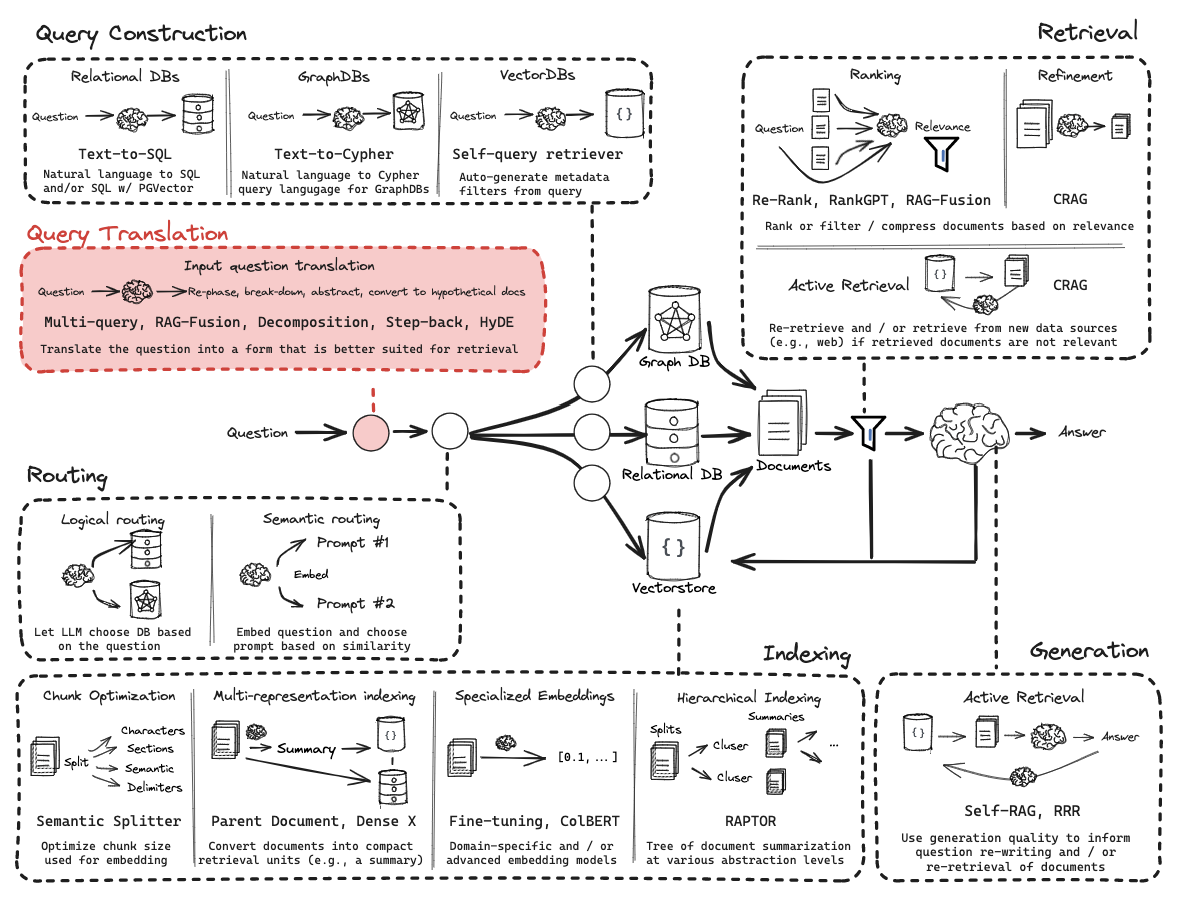

In [1]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [2]:
import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_PROJECT'] = 'advance-rag'
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")

In [3]:
from langchain_groq import ChatGroq
llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)

c:\Users\visha\anaconda3\envs\advance_rag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import sys

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\visha\anaconda3\envs\advance_rag\python.exe
Torch: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [5]:
import bs4
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import ChatPromptTemplate

website_urls = ("https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones", )
loader = WebBaseLoader(
    web_paths=website_urls,
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", 'post-title', 'post-header' )
    )
    )
)
docs = loader.load()

# Split - chunking
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
splits = text_splitter.split_documents(docs)

#Embeddings

model_name = "BAAI/bge-large-en-v1.5"
hf_embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={
        "device": "cuda",  # Use RTX 4070
    },
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 32,
    },
)

## Vector store

vectorstore = FAISS.from_documents(documents=splits, 
                                    embedding=hf_embeddings)

C:\Users\visha\AppData\Local\Temp\ipykernel_12980\2755418415.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2625.19it/s]


In [6]:
retriever = vectorstore.as_retriever()

## Part 5: Multi Query

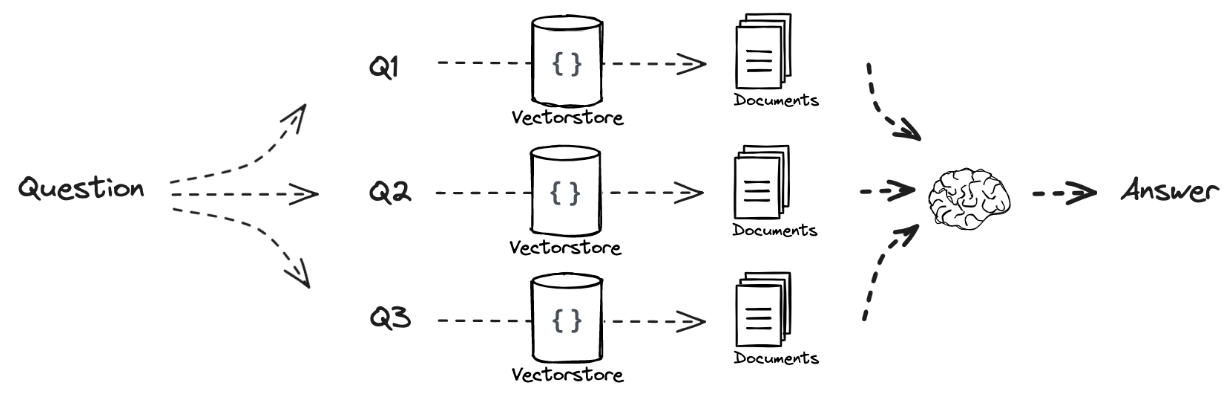

In [7]:
from langchain_core.prompts import ChatPromptTemplate

#Multi-query
template = """You are an AI language model assistant. Your task is to generate five different versions
of the given user questions to retrieve relevant documents from a vector database. By generating multiple perspectives
on the user question, your goal is to help the user overcome some of limitations of distance based similarity search.
Provide the alternative questions seperated by newlines. Original question: {question}"""
prompt_perspectives = ChatPromptTemplate.from_template(template)

generate_queries = (
    prompt_perspectives
    | llm
    | StrOutputParser()
    | (lambda x: [q.strip() for q in x.split("\n") if q.strip()])
)

In [8]:
generate_queries.invoke("Who is Tywin Lannister?")

['Who is the patriarch of House Lannister in the Game of Thrones series?',
 'What is the role of Tywin Lannister in the Game of Thrones universe?',
 'Who plays the character of Tywin Lannister in the HBO adaptation of Game of Thrones?',
 'What are the notable actions and decisions of Tywin Lannister throughout the Game of Thrones story?',
 'Can you provide information about the character Tywin Lannister, including his backstory and relationships with other characters?']

In [9]:
from langchain_core.load import loads, dumps

def get_unique_union(documents : list[list]):
    """Unique union of retrieved documents"""
    # Flaten the list of list and convert each to document string
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    # Get unique documents
    unique_docs = list(set(flattened_docs))
    #return
    return [loads(doc)for doc in unique_docs]


# Retrieve
question = "Why is Tywin Lannister so famous?"
retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs = retrieval_chain.invoke({"question":question})
print(len(docs)) 

9


C:\Users\visha\AppData\Local\Temp\ipykernel_12980\3974223782.py:10: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  return [loads(doc)for doc in unique_docs]
C:\Users\visha\AppData\Local\Temp\ipykernel_12980\3974223782.py:10: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc)for doc in unique_docs]


In [10]:
docs

[Document(id='caad2308-2fec-4194-ad12-1932de58c5ee', metadata={'source': 'https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones'}, page_content='Tyrion Lannister, the dwarf brother of the queen decides to go with Jon Snow towards the wall to know the border between the civilized kingdom and the kingdom of the savages, and between him and Jon a strange friendship will be formed.'),
 Document(id='4227bb29-1494-45ac-8684-551b8f13e78e', metadata={'source': 'https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones'}, page_content='And Cat travels to the capital to alert Ned, on the way back to Winterfell, Cat, is the dwarf Tyrion who came from the wall and intrigues of Lord Baelish who was his childhood friend, captures him and takes him prisoner thinking that he tried to kill Bran, but that leads to a fight between Ned and Jamie Lannister, in the fight Ned is wounded and on awakening the king asks him to free the dwarf and ar

In [11]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

#RAG
template = """
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If the answer is not contained in the context, say "I don't know."
Keep the answer concise and limited to five sentences.
Context:
{context}
Question:
{question}
Answer:
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain,
     "question": itemgetter("question")}
    | prompt
    | llm
    | StrOutputParser()
)

question = "Why is Tywin Lannister critizied?"
final_rag_chain.invoke({'question':question})

C:\Users\visha\AppData\Local\Temp\ipykernel_12980\3974223782.py:10: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc)for doc in unique_docs]


'Tywin Lannister is not explicitly criticized in the context, but it is mentioned that he was humiliated by the Mad King when he proposed that his daughter Cersei marry the crown prince Rhaegar, and the Mad King mocked Tywin and his pretensions. Additionally, the brother of Ellia Martell seeks revenge against the Lannisters, specifically "The Mountain", a Lannister soldier who murdered Ellia.'

## Part 6: RAG Fusion

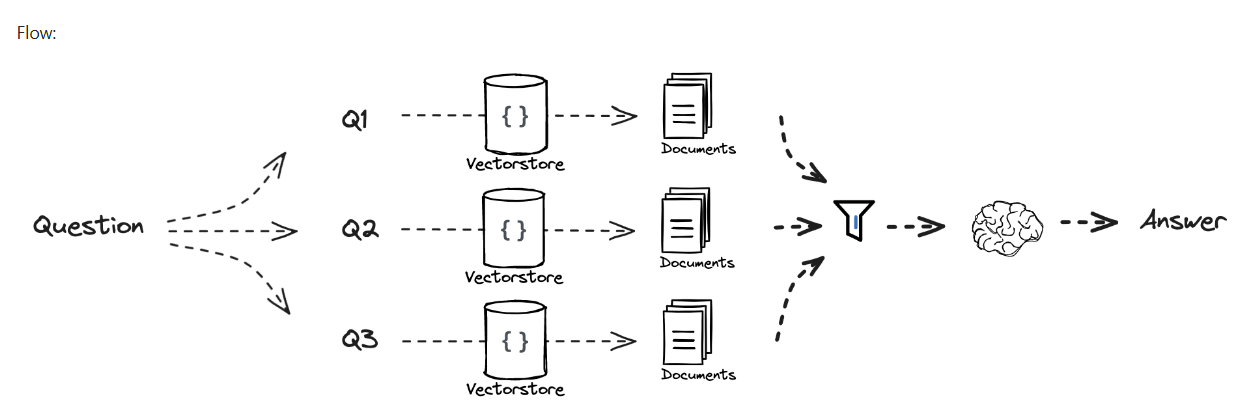

In [12]:
from langchain_core.prompts import ChatPromptTemplate

template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Only give the queries, don't print anything else. Generate multiple queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [13]:
from langchain_core.output_parsers import StrOutputParser

generate_queries = (
    prompt_rag_fusion
    | llm
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

generate_queries.invoke('Which house does Ned stark belongs to?')

['Which house does Eddard Stark belong to in Game of Thrones',
 'Ned Stark family house name',
 'House of the Warden of the North in Game of Thrones',
 'Stark family house in Westeros']

In [14]:
from  langchain_core.load import loads, dumps

def recriprocal_rank_fusion(results: list[list], k=60):
    
    fused_scores = {}
    
    for docs in results:
        for rank, doc in enumerate(docs):
            doc_str = dumps(doc)
            if doc_str not in fused_scores:
                fused_scores[doc_str]=0
            previous_score = fused_scores[doc_str]
            fused_scores[doc_str] += 1 / (rank + k)
            
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x:x[1], reverse=True)
    ]
    
    return reranked_results

retrieval_chain_rag_fusion = generate_queries | retriever.map() | recriprocal_rank_fusion

question = "Why is Tywin lannister famous?"
docs = retrieval_chain_rag_fusion.invoke({'question': question})
print(len(docs))

9


C:\Users\visha\AppData\Local\Temp\ipykernel_12980\2597591402.py:16: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


In [15]:
docs

[(Document(id='19546d46-20f8-4263-8e51-9fe4c2d1b185', metadata={'source': 'https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones'}, page_content='That hand was a man named Tywin Lannister, who was constantly humiliated by the king because of the comments about Tywin driving the kingdom, but was offended and definitely distanced from the so-called Mad King when Tywin proposed to him that his daughter Cersei, He married the crown prince Rhaegar, but the mad king mocked Tywin and his pretensions.'),
  0.05),
 (Document(id='b58b8df6-a089-4cea-abf9-70585e133c26', metadata={'source': 'https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones'}, page_content='At the orders of the queen, a soldier Lannister tried to kill him, slashed him in the face and when he was about to kill him, Podrick, his squire, saved his life. When Tyrion awakens, he discovers that his father arrived with his armies and he stole all the merit of victory,

In [16]:
from langchain_core.runnables import RunnablePassthrough

#RAG
template = """
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If the answer is not contained in the context, say "I don't know."
Keep the answer concise and limited to five sentences.
Context:
{context}
Question:
{question}
Answer:
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context":retrieval_chain_rag_fusion,
     "question": itemgetter('question')}
    | prompt
    | llm
    | StrOutputParser()
)

question = "Who is Tywin to Jofrey?"
final_rag_chain.invoke({"question": question})

C:\Users\visha\AppData\Local\Temp\ipykernel_12980\2597591402.py:16: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


"Tywin Lannister is Joffrey's grandfather."

## Part 7: Decomposition

In [17]:
from langchain_core.prompts import ChatPromptTemplate

# Decomposition
template = """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answered in isolation. \n
Don't give any additional commas or any exclamation after each sentences. \n
Generate multiple search queries related to: {question} \n
Output (3 queries):"""
prompt_decomposition = ChatPromptTemplate.from_template(template)

In [18]:
# Chain
generate_queries_decomposition = (prompt_decomposition | llm | StrOutputParser() | (lambda x: x.split("\n")))

#Run
question = "What is the significance of battle of bastards?"
questions = generate_queries_decomposition.invoke({'question':question})

questions

['What were the main events of the battle of bastards ',
 'What were the consequences of the battle of bastards ',
 'Who were the key players involved in the battle of bastards']

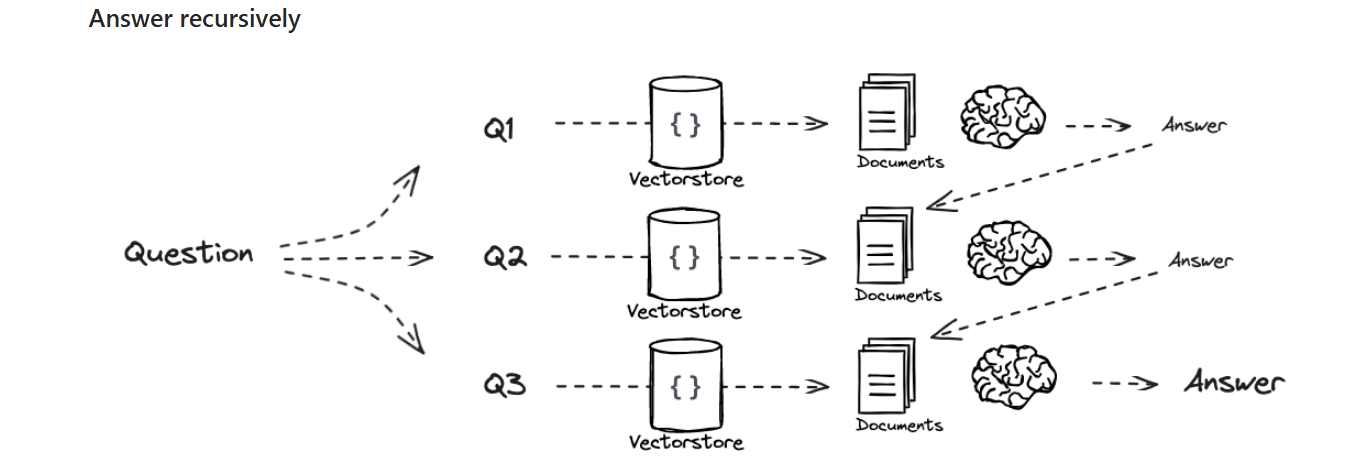

In [22]:
# Prompt

template = """Here is the question you need to answer:

\n --- \n {question} \n --- \n

Here is any available background questions + answer pairs:

\n --- \n {q_a_pairs} \n --- \n

Here is the additional context relevant to the question:

\n --- \n {context} \n --- \n

Use the above context and any background question + answer pairs to answer the question: \n {question} 
"""

decomposition_prompt = ChatPromptTemplate.from_template(template)

In [23]:
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

def format_qa_pairs(question, answer):
    """Format Q and A pair"""
    formatted_string = ""
    formatted_string += f"Question: {question}\nAnswer: {answer}\n\n"
    return formatted_string.strip()

q_a_pairs = ""
for q in questions:
    
    rag_chain = (
        {"context": itemgetter('question') | retriever,
         "question": itemgetter("question"),
         "q_a_pairs": itemgetter("q_a_pairs")}
        | decomposition_prompt
        | llm
        | StrOutputParser()
    )
    
    answer = rag_chain.invoke({'question':q, "q_a_pairs":q_a_pairs})
    q_a_pair = format_qa_pairs(q, answer)
    q_a_pairs = q_a_pair + "\n --- \n" + q_a_pair

In [25]:
print(answer)

The key players involved in the Battle of the Bastards were:

1. Jon Snow: The leader of the Stark forces, who led the charge against the Bolton army.
2. Ramsey Bolton: The leader of the Bolton army, who was determined to defend Winterfell and his claim to the North.
3. Sansa Stark: Jon's sister, who played a crucial role in gathering support from the Northern lords and securing the help of Littlefinger and the Arryn Valley forces.
4. Littlefinger: The lord of the Vale, who arrived with his army to support the Starks and turned the tide of the battle in their favor.
5. Rickon Stark: Jon's younger brother, who was killed by Ramsey Bolton during the battle, which sparked Jon's anger and determination to defeat the Boltons.

These characters were the main players in the Battle of the Bastards, which was a pivotal moment in the Game of Thrones series. The battle was fought between the Stark forces, led by Jon Snow, and the Bolton army, led by Ramsey Bolton, with the goal of reclaiming Wint

## Part 8: Step back

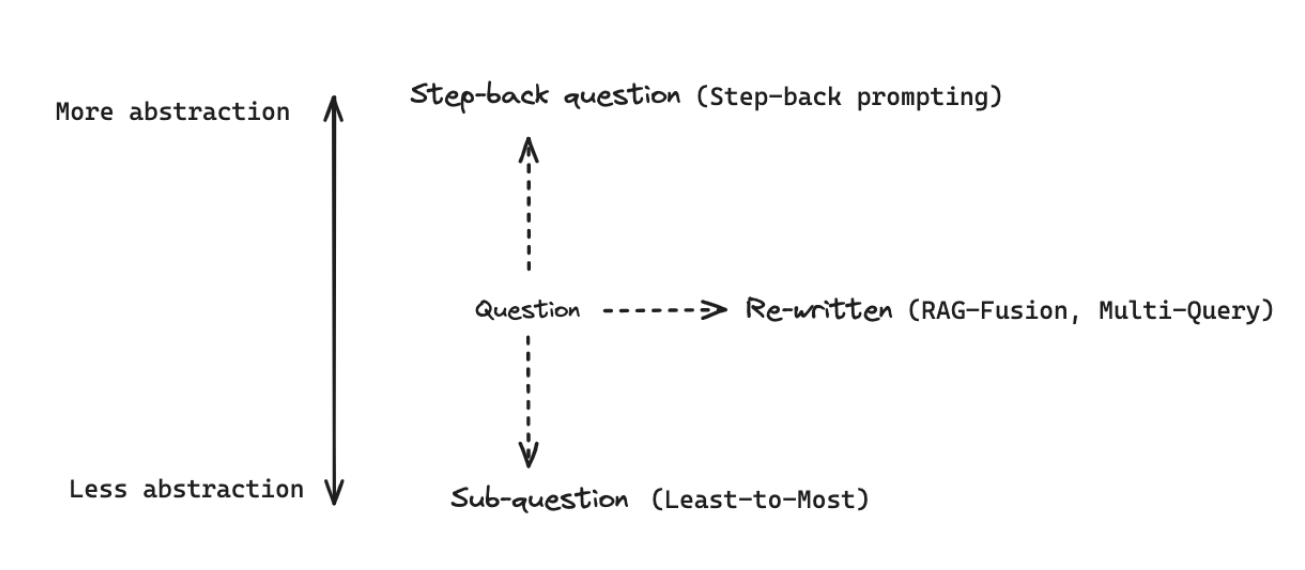

In [26]:
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate
examples = [
    {
        "input": "Could the members of the police can perform lawful arrests?",
        "output": "What can the members of The police do?"
    },
    {
        "input": "Jan Sindel's was born in what country?",
        "output": "What is Jan Sindel's personal history"
    }
]

# We now transform these to example messages
example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}"),
    ]
)

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples
)

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are an expert at world knowledge. Your task is to step back and paraphrase a question to ask more 
            generic step-back question, which is easier to answer. Here are few examples:"""
        ),
        #Few shot examples
        few_shot_prompt,
        #New question
        ("user", "{question}")
    ]
)

In [28]:
generate_queries_step_back = prompt | llm | StrOutputParser()
question = "What business does Lord Tywin do?"
generate_queries_step_back.invoke({'question':question})

"What is Lord Tywin's occupation?"

In [30]:
from langchain_core.runnables import RunnableLambda

# Response prompt 
response_prompt_template = """You are an expert of world knowledge. I am going to ask you a question. Your response should be comprehensive and not contradicted with the following context if they are relevant. Otherwise, ignore them if they are not relevant.

# {normal_context}
# {step_back_context}

# Original Question: {question}
# Answer:"""
response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retrieve context using the normal question
        "normal_context": RunnableLambda(lambda x: x["question"]) | retriever,
        # Retrieve context using the step-back question
        "step_back_context": generate_queries_step_back | retriever,
        # Pass on the question
        "question": lambda x: x["question"],
    }
    | response_prompt
    | llm
    | StrOutputParser()
)

chain.invoke({"question": question})

'Based on the provided context, it appears that Lord Tywin Lannister is involved in the governance and military leadership of the kingdom, rather than a specific business in the classical sense. As the head of House Lannister, he is a noble lord and a key player in the political and military affairs of the realm.\n\nIn the context of the documents, Lord Tywin is described as the Hand of the King, who was "constantly humiliated by the king" and later led a great army to the capital. He is also mentioned as being the judge in the trial of his son Tyrion, and as having arrived with his armies to steal the merit of victory. This suggests that his primary role is that of a military leader and a noble lord, rather than a businessman.\n\nHowever, it is worth noting that the Lannisters are known to be a wealthy and influential family, and they do have significant economic interests, particularly in the gold mines of the Westerlands. But based on the provided context, it is not possible to dete

## Part 9: HyDE

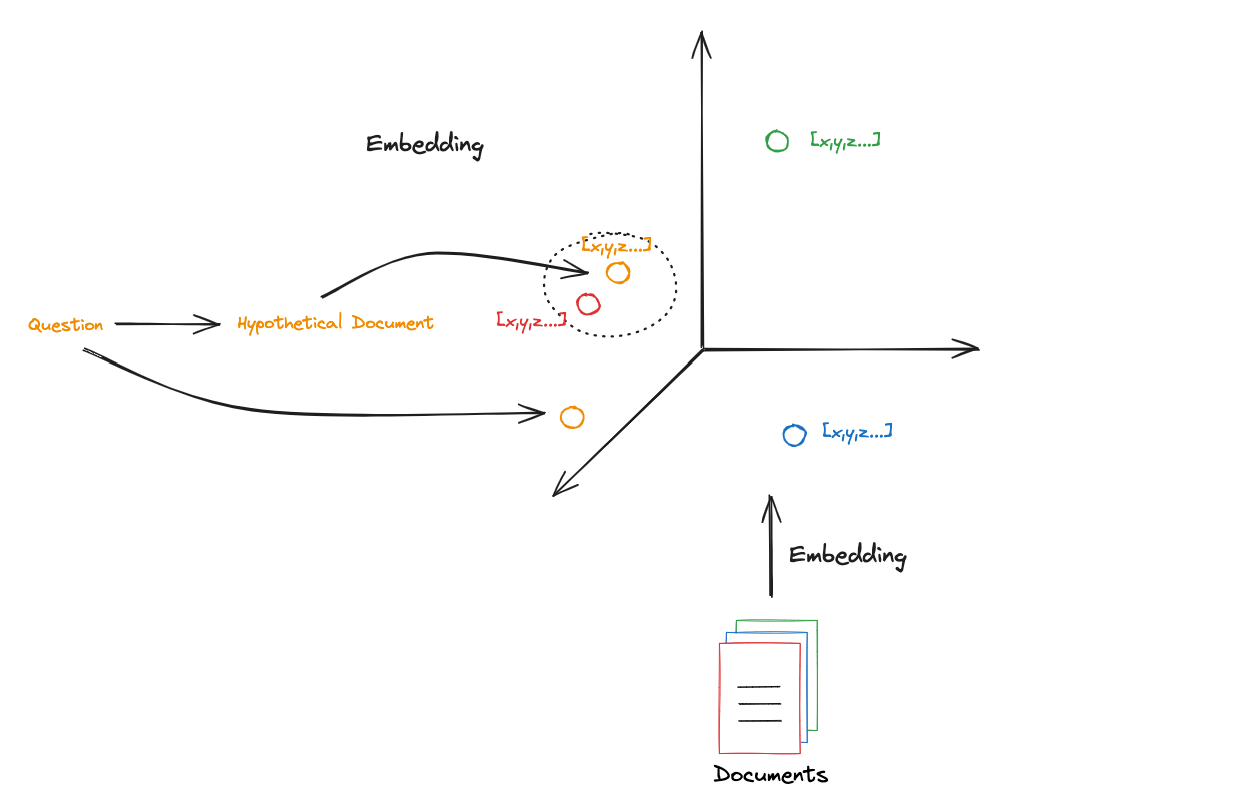

In [38]:
from langchain_core.prompts import ChatPromptTemplate

# HyDE document generation
template = """Please write a hypothetical paper passage to answer the question
Question: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_template(template)

from langchain_core.output_parsers import StrOutputParser

generate_docs_for_retrieval = (
    prompt_hyde | llm | StrOutputParser()
)

question = "Who is Tywin Lannister"
result = generate_docs_for_retrieval.invoke({'question':question})
print(result)

Tywin Lannister is a pivotal character in the fictional world of Westeros, created by author George R.R. Martin. As the patriarch of House Lannister, one of the most powerful and influential families in the Seven Kingdoms, Tywin is a masterful politician, strategist, and military commander. He is the Lord of Casterly Rock, the Warden of the West, and the Hand of the King to multiple monarchs, including King Aerys II Targaryen and his son, King Joffrey Baratheon.

Throughout his life, Tywin has demonstrated unwavering dedication to his family's honor and legacy, often at the expense of personal relationships and emotional connections. His unyielding commitment to duty and his unrelenting pursuit of power have earned him both respect and fear from his peers. As a skilled military leader, Tywin has successfully led armies to victory in numerous battles, including the Rebellion that overthrew the Targaryen dynasty and the War of the Ninepenny Kings.

Despite his impressive accomplishments,

In [39]:
# Retrieve
retrieve_chain = generate_docs_for_retrieval | retriever
retriever_docs = retrieve_chain.invoke({"question":question})
retriever_docs

[Document(id='19546d46-20f8-4263-8e51-9fe4c2d1b185', metadata={'source': 'https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones'}, page_content='That hand was a man named Tywin Lannister, who was constantly humiliated by the king because of the comments about Tywin driving the kingdom, but was offended and definitely distanced from the so-called Mad King when Tywin proposed to him that his daughter Cersei, He married the crown prince Rhaegar, but the mad king mocked Tywin and his pretensions.'),
 Document(id='f46a7cb6-9fc1-41ba-a20f-a1bf301af04c', metadata={'source': 'https://steemit.com/ocd/@albertocotua/brief-summary-of-what-happened-in-game-of-thrones'}, page_content='And well Robert recovers from his wounds, and occupies the iron throne, marries Cersei the daughter of Tywin Lannister who by the way is the richest man in Westeros, Ned names him guardian of the north and everyone goes home .\nBut when Ned comes home he has a little surprise under his

In [41]:
# RAG 

template = """Answer the following based on this context:

{context}

Question: {question}"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    |llm
    | StrOutputParser()
)

result = final_rag_chain.invoke({"context":retriever_docs, "question": question})
print(result)

According to the provided context, Tywin Lannister is:

1. A man who was constantly humiliated by the king (also known as the Mad King) due to comments about Tywin driving the kingdom.
2. The father of Cersei Lannister, whom he proposed to marry to the crown prince Rhaegar, but was mocked by the Mad King.
3. The richest man in Westeros.
4. The father of Tyrion Lannister and Jaime Lannister.
5. A judge who wants to see Tyrion dead, but is convinced by Jaime to spare his life.

Overall, Tywin Lannister appears to be a significant and influential character in the Game of Thrones series, known for his wealth, family, and complex relationships with other characters.
